# Principal Component Analysis (PCA) - Function Implementation

In this notebook, we create a reusable PCA function that takes:
- **Observation matrix** (data): n_samples × n_features
- **Number of components**: How many principal components to compute

The function returns the transformed data in the lower-dimensional PCA space.

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


## PCA Function Definition

Create a comprehensive PCA function that encapsulates all steps.

In [2]:
def perform_pca(X, n_components):
    """
    Perform Principal Component Analysis on the observation matrix.
    
    Parameters:
    -----------
    X : numpy.ndarray
        Observation matrix of shape (n_samples, n_features)
        Each row is an observation, each column is a feature.
    
    n_components : int
        Number of principal components to retain.
        Must be <= min(n_samples, n_features)
    
    Returns:
    --------
    dict : Dictionary containing:
        - 'X_pca': Transformed data (n_samples, n_components)
        - 'explained_variance': Variance explained by each PC
        - 'cumulative_variance': Cumulative variance ratio
        - 'projection_matrix': Eigenvectors used for projection (n_features, n_components)
        - 'mean': Mean of original data (used for centering)
    """
    
    # Validate input
    if not isinstance(X, np.ndarray):
        X = np.array(X)
    
    n_samples, n_features = X.shape
    
    if n_components > min(n_samples, n_features):
        raise ValueError(
            f"n_components ({n_components}) cannot exceed "
            f"min(n_samples, n_features) = {min(n_samples, n_features)}"
        )
    
    # Step 1: Center the data
    X_mean = X.mean(axis=0)
    X_centered = X - X_mean
    
    # Step 2: Compute covariance matrix
    cov_matrix = np.cov(X_centered.T)
    
    # Step 3: Compute eigenvalues and eigenvectors
    eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
    
    # Ensure real values (discard negligible imaginary parts from numerical precision)
    eigenvalues = np.real(eigenvalues)
    eigenvectors = np.real(eigenvectors)
    
    # Step 4: Sort by eigenvalues in descending order
    idx = eigenvalues.argsort()[::-1]
    eigenvalues_sorted = eigenvalues[idx]
    eigenvectors_sorted = eigenvectors[:, idx]
    
    # Step 5: Select top n_components eigenvectors
    projection_matrix = eigenvectors_sorted[:, :n_components]
    
    # Step 6: Project data onto principal components
    X_pca = X_centered @ projection_matrix
    
    # Step 7: Calculate explained variance
    total_variance = eigenvalues_sorted.sum()
    explained_variance = eigenvalues_sorted / total_variance
    cumulative_variance = np.cumsum(explained_variance)
    
    return {
        'X_pca': X_pca,
        'explained_variance': explained_variance,
        'cumulative_variance': cumulative_variance,
        'projection_matrix': projection_matrix,
        'mean': X_mean,
        'eigenvalues': eigenvalues_sorted
    }

print("PCA function defined successfully!")

PCA function defined successfully!


## Example 1: PCA on 5D Data → 2D

In [3]:
# Set random seed for reproducibility
np.random.seed(42)

# Create sample dataset: 100 observations, 5 variables
n_observations = 100
n_variables = 5

base = np.random.randn(n_observations, 2)
X_sample = np.hstack([
    base[:, 0:1],
    base[:, 1:2],
    base[:, 0:1] + 0.5 * base[:, 1:2],
    base[:, 1:2] + 0.3 * base[:, 0:1],
    np.random.randn(n_observations, 1)
])

print(f"Original data shape: {X_sample.shape}")
print()

# Apply PCA to reduce to 2 components
pca_result = perform_pca(X_sample, n_components=2)

print("PCA Result Summary:")
print(f"Transformed data shape: {pca_result['X_pca'].shape}")
print()
print("Explained Variance Ratio:")
for i, (var, cum_var) in enumerate(zip(pca_result['explained_variance'][:3], 
                                         pca_result['cumulative_variance'][:3])):
    print(f"  PC{i+1}: {var*100:.2f}% (Cumulative: {cum_var*100:.2f}%)")
print()
print(f"Data reduced from {n_variables}D to 2D")
print(f"Variance preserved: {pca_result['cumulative_variance'][1]*100:.2f}%")

Original data shape: (100, 5)

PCA Result Summary:
Transformed data shape: (100, 2)

Explained Variance Ratio:
  PC1: 54.88% (Cumulative: 54.88%)
  PC2: 27.34% (Cumulative: 82.22%)
  PC3: 17.78% (Cumulative: 100.00%)

Data reduced from 5D to 2D
Variance preserved: 82.22%


### Visualize the Transformation

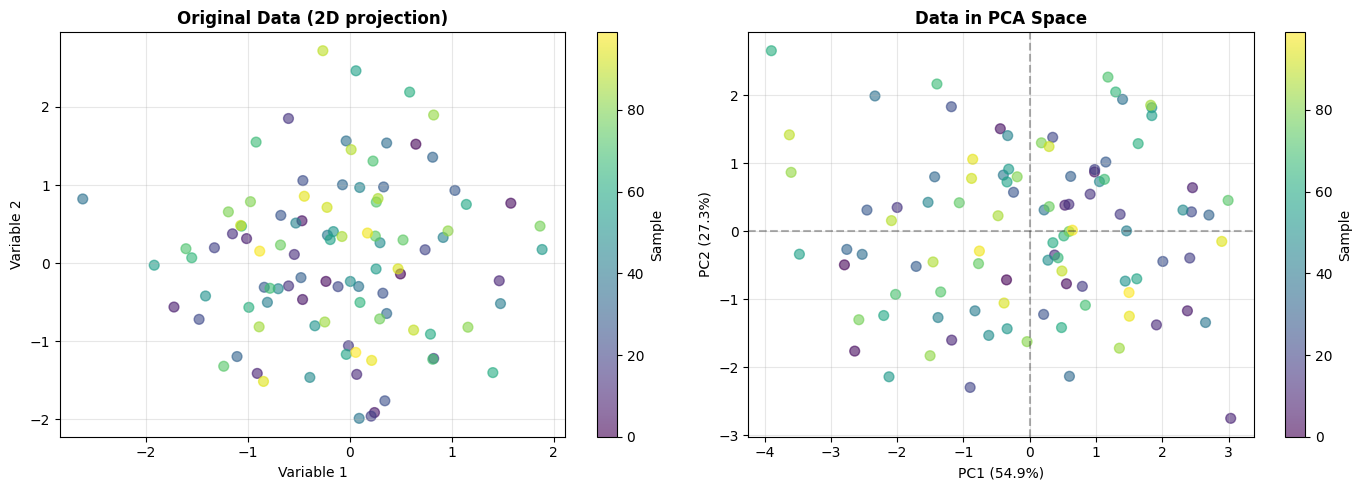

In [4]:
# Visualize original vs PCA space
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original 2D projection (first 2 variables)
ax = axes[0]
scatter1 = ax.scatter(X_sample[:, 0], X_sample[:, 1], 
                      c=np.arange(n_observations), cmap='viridis', 
                      alpha=0.6, s=50)
ax.set_xlabel('Variable 1')
ax.set_ylabel('Variable 2')
ax.set_title('Original Data (2D projection)', fontweight='bold')
ax.grid(alpha=0.3)
plt.colorbar(scatter1, ax=ax, label='Sample')

# PCA transformed data
ax = axes[1]
var1 = pca_result['explained_variance'][0] * 100
var2 = pca_result['explained_variance'][1] * 100
scatter2 = ax.scatter(pca_result['X_pca'][:, 0], pca_result['X_pca'][:, 1],
                      c=np.arange(n_observations), cmap='viridis',
                      alpha=0.6, s=50)
ax.set_xlabel(f'PC1 ({var1:.1f}%)')
ax.set_ylabel(f'PC2 ({var2:.1f}%)')
ax.set_title('Data in PCA Space', fontweight='bold')
ax.grid(alpha=0.3)
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)
plt.colorbar(scatter2, ax=ax, label='Sample')

plt.tight_layout()
plt.show()

## Example 2: PCA on Different Dataset Sizes

In [5]:
# Create a larger dataset with more features
np.random.seed(123)
X_large = np.random.randn(200, 10)  # 200 samples, 10 features

print("Testing PCA on different component numbers:")
print(f"Original data shape: {X_large.shape}")
print()

# Test with different component counts
for n_comp in [2, 3, 5]:
    result = perform_pca(X_large, n_components=n_comp)
    cum_var = result['cumulative_variance'][n_comp-1]
    print(f"n_components={n_comp}: "
          f"Shape={result['X_pca'].shape}, "
          f"Cumulative Variance={cum_var*100:.2f}%")

Testing PCA on different component numbers:
Original data shape: (200, 10)

n_components=2: Shape=(200, 2), Cumulative Variance=26.60%
n_components=3: Shape=(200, 3), Cumulative Variance=38.67%
n_components=5: Shape=(200, 5), Cumulative Variance=59.79%


## Example 3: Scree Plot - Explained Variance

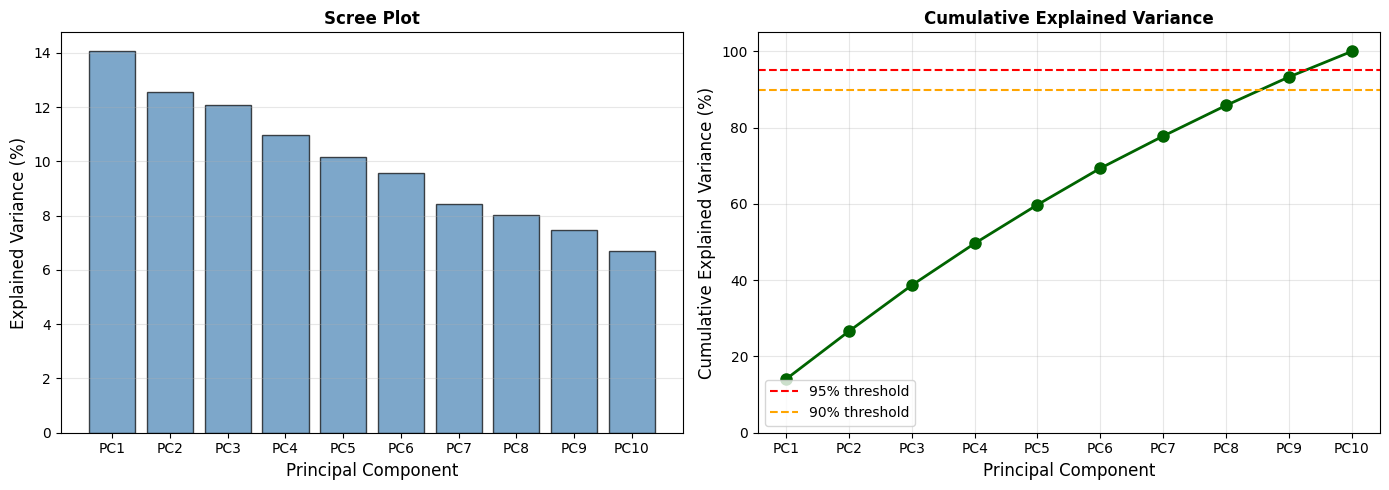

Components needed for 95% variance: 10
Actual variance captured: 100.00%


In [6]:
# Get all components to show full scree plot
pca_full = perform_pca(X_large, n_components=10)

# Create scree plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot (individual variance)
ax = axes[0]
pc_labels = [f'PC{i+1}' for i in range(10)]
ax.bar(pc_labels, pca_full['explained_variance'] * 100, 
       color='steelblue', alpha=0.7, edgecolor='black')
ax.set_ylabel('Explained Variance (%)', fontsize=12)
ax.set_xlabel('Principal Component', fontsize=12)
ax.set_title('Scree Plot', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Cumulative variance plot
ax = axes[1]
ax.plot(pc_labels, pca_full['cumulative_variance'] * 100, 
        'o-', linewidth=2, markersize=8, color='darkgreen')
ax.axhline(y=95, color='red', linestyle='--', label='95% threshold')
ax.axhline(y=90, color='orange', linestyle='--', label='90% threshold')
ax.set_ylabel('Cumulative Explained Variance (%)', fontsize=12)
ax.set_xlabel('Principal Component', fontsize=12)
ax.set_title('Cumulative Explained Variance', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
ax.set_ylim([0, 105])

plt.tight_layout()
plt.show()

# Find number of components for 95% variance
n_comp_95 = np.argmax(pca_full['cumulative_variance'] >= 0.95) + 1
print(f"Components needed for 95% variance: {n_comp_95}")
print(f"Actual variance captured: {pca_full['cumulative_variance'][n_comp_95-1]*100:.2f}%")

## Example 4: Function Usage Pattern

In [7]:
# Demonstrate common usage patterns
print("=== PCA Function Usage Patterns ===")
print()

# Pattern 1: Simple usage
print("1. Basic usage:")
result = perform_pca(X_sample, n_components=2)
X_pca = result['X_pca']
print(f"   Input:  {X_sample.shape}")
print(f"   Output: {X_pca.shape}")
print()

# Pattern 2: Accessing explained variance
print("2. Check explained variance:")
for i, var in enumerate(result['explained_variance'][:2]):
    print(f"   PC{i+1}: {var*100:.2f}%")
print()

# Pattern 3: Using projection matrix for new data
print("3. Project new data using same transformation:")
X_new = np.random.randn(5, 5)  # 5 new samples, 5 features
X_new_centered = X_new - result['mean']  # Center using original mean
X_new_pca = X_new_centered @ result['projection_matrix']  # Project
print(f"   New data shape: {X_new.shape}")
print(f"   Projected shape: {X_new_pca.shape}")
print()

# Pattern 4: Eigenvalues
print("4. Eigenvalues (variance in each direction):")
for i, eig in enumerate(result['eigenvalues'][:3]):
    print(f"   λ{i+1}: {eig:.4f}")

=== PCA Function Usage Patterns ===

1. Basic usage:
   Input:  (100, 5)
   Output: (100, 2)

2. Check explained variance:
   PC1: 54.88%
   PC2: 27.34%

3. Project new data using same transformation:
   New data shape: (5, 5)
   Projected shape: (5, 2)

4. Eigenvalues (variance in each direction):
   λ1: 2.7427
   λ2: 1.3662
   λ3: 0.8885


## Summary

### PCA Function Features:
- Takes observation matrix and number of components
- Automatically centers data
- Computes covariance and eigendecomposition
- Returns transformed data and variance ratios
- Suitable for dimensionality reduction

### Key Outputs:
1. **X_pca**: Transformed data in lower-dimensional space
2. **explained_variance**: How much variance each PC explains
3. **projection_matrix**: Can be used for projecting new data
4. **mean**: Needed to center new data before projection

### Usage Example:
```python
# Reduce 10D data to 3D
result = perform_pca(X_data, n_components=3)
X_reduced = result['X_pca']
variance = result['cumulative_variance'][2]
```